> **Disclaimer**  
> All notebooks in this repository were executed using Google Colab.  
> The dataset is stored in Google Drive and is not included in this repository due to privacy and storage considerations.  
> File paths may need to be updated to match your own Google Drive directory structure before running the code.

In [ ]:
from google.colab import drive
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dir_name = '/content/drive/MyDrive/THESIS/Data/Multivariate Data/'
df = pd.read_csv(f"{dir_name}[Raw]Multivariate_Data.csv")
print(df.head())

   Year  Month  Day        Date  Residential Monthly Average  \
0  2010      1    1  2010-01-01                      4940168   
1  2010      1    2  2010-01-02                      4940168   
2  2010      1    3  2010-01-03                      4940168   
3  2010      1    4  2010-01-04                      4940168   
4  2010      1    5  2010-01-05                      4940168   

   Residential Daily Average  Commercial Monthly Average  \
0                5219177.471                      702499   
1                5369780.602                      702499   
2                5260723.163                      702499   
3                5110120.032                      702499   
4                5245143.528                      702499   

   Commercial Daily Average  Government Monthly Average  \
0               742174.5484                      156935   
1               763590.5304                      156935   
2               748082.4055                      156935   
3               72

In [ ]:
# Convert the existing 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as index if needed
df.set_index('Date', inplace=True)

In [ ]:
# Specify columns to keep
columns_to_keep = [
    'Residential Daily Average', 'Commercial Daily Average',
    'Government Daily Average',
    'RAINFALL', 'TMAX', 'TMIN', 'TMEAN', 'WIND_SPEED', 'WIND_DIRECTION',  'RH'
]

# Calculate the Spearman correlation matrix
spearman_corr = df.corr(method='spearman')

# Filter the correlation matrix to keep only relevant columns
spearman_corr_filtered = spearman_corr.loc[columns_to_keep, columns_to_keep]

# Display the filtered Spearman correlation matrix as a table
print("Filtered Spearman Correlation Matrix:")
print(spearman_corr_filtered.round(3).to_string())

Filtered Spearman Correlation Matrix:
                           Residential Daily Average  Commercial Daily Average  Government Daily Average  RAINFALL   TMAX   TMIN  TMEAN  WIND_SPEED  WIND_DIRECTION     RH
Residential Daily Average                      1.000                     0.711                     0.766    -0.432  0.250  0.379  0.360       0.140          -0.111 -0.520
Commercial Daily Average                       0.711                     1.000                     0.830    -0.269  0.138  0.279  0.232       0.176          -0.134 -0.450
Government Daily Average                       0.766                     0.830                     1.000    -0.254  0.178  0.300  0.269       0.139          -0.142 -0.506
RAINFALL                                      -0.432                    -0.269                    -0.254     1.000 -0.167 -0.254 -0.243      -0.139          -0.022  0.414
TMAX                                           0.250                     0.138                     0.178   

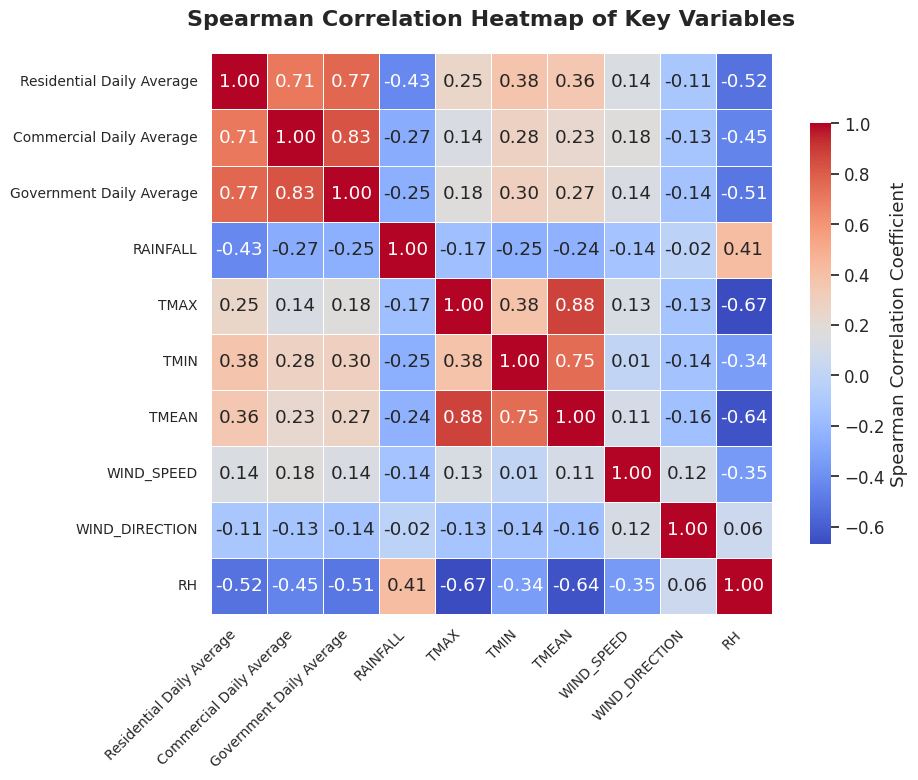

In [ ]:
# Define the columns to keep for the filtered correlation matrix
columns_to_keep = [
    'Residential Daily Average', 'Commercial Daily Average',
    'Government Daily Average',
    'RAINFALL', 'TMAX', 'TMIN', 'TMEAN', 'WIND_SPEED', 'WIND_DIRECTION',  'RH'
]

spearman_corr_filtered = spearman_corr.loc[columns_to_keep, columns_to_keep]

# Set up the plot style for a publication-ready heatmap
plt.figure(figsize=(10, 8))  # Adjust figure size
sns.set(font_scale=1.1)  # Increase font scale for readability
sns.heatmap(
    spearman_corr_filtered,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.75, "aspect": 20, "label": "Spearman Correlation Coefficient"}  # Adjust color bar
)

# Add title and labels
plt.title('Spearman Correlation Heatmap of Key Variables', fontsize=16, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

# Correlation Results: Daily Averages vs Selected Features (TMEAN, RH)

## Method
Correlation metric: **Spearman correlation coefficient (ρ)**  
Selected predictors:
- **TMEAN** — Mean daily temperature  
- **RH** — Relative humidity  

Correlation strength guide:
- **Strong:** |ρ| ≥ 0.50  
- **Moderate:** 0.30–0.49  
- **Weak:** < 0.30  

---

# Results

## Residential Daily Average
| Feature | Spearman ρ | Strength | Interpretation |
|---|---|---|---|
| TMEAN | 0.36 | Moderate positive | Higher mean temperature is associated with higher residential electricity demand |
| RH | -0.52 | Strong negative | Higher humidity is associated with significantly lower residential electricity demand |

---

## Commercial Daily Average
| Feature | Spearman ρ | Strength | Interpretation |
|---|---|---|---|
| TMEAN | 0.23 | Weak positive | Temperature has limited influence on commercial demand |
| RH | -0.45 | Moderate negative | Higher humidity tends to reduce commercial electricity demand |

---

## Government Daily Average
| Feature | Spearman ρ | Strength | Interpretation |
|---|---|---|---|
| TMEAN | 0.27 | Weak–moderate positive | Temperature moderately increases government electricity demand |
| RH | -0.51 | Strong negative | Higher humidity significantly reduces government electricity demand |

---

# Key Findings

## Relative Humidity (RH)
- Strong negative correlation with:
  - Residential demand (ρ = -0.52)
  - Government demand (ρ = -0.51)
- Moderate negative correlation with:
  - Commercial demand (ρ = -0.45)

**Conclusion:** Relative humidity is the strongest predictor among selected features.

---

## Mean Temperature (TMEAN)
- Moderate positive correlation with residential demand (ρ = 0.36)
- Weak to moderate correlation with commercial and government demand (ρ = 0.23–0.27)

**Conclusion:** Temperature is a secondary but useful predictor.

---

# Overall Conclusion

- **RH is the strongest predictor of water demand**
- **TMEAN is a useful secondary predictor**
- Both features show consistent relationships across all sectors
- These variables are suitable for predictive modeling of electricity demand